In [1]:
#pip install --upgrade pip


In [2]:

#pip install nltk

In [3]:
!pip install wordcloud

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [5]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
ps = PorterStemmer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
# 1. Data Loading and Cleaning

In [7]:
df = pd.read_csv('amazonreviews.tsv', sep='\t')
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [9]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.shape

(10000, 2)

In [10]:
#/Clean text preprocessing function
def clean_text(text):
    text = text.lower()                                # Lowercase
    text = re.sub('[^a-zA-Z]', ' ', text)              # Remove non-letters
    text = text.split()                                # Tokenize
    text = [ps.stem(word) for word in text if word not in stop_words]
    text = " ".join(text)
    return text

In [11]:
# Apply cleaning
df['clean_review'] = df['review'].apply(clean_text)
df.head()

,label,review,clean_review
0,pos,Stuning even for the non-gamer: This sound tra...,stune even non gamer sound track beauti paint ...
1,pos,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anyth read lot review say...
2,pos,Amazing!: This soundtrack is my favorite music...,amaz soundtrack favorit music time hand intens...
3,pos,Excellent Soundtrack: I truly like this soundt...,excel soundtrack truli like soundtrack enjoy v...
4,pos,"Remember, Pull Your Jaw Off The Floor After He...",rememb pull jaw floor hear play game know divi...


In [12]:
# 2.EDA

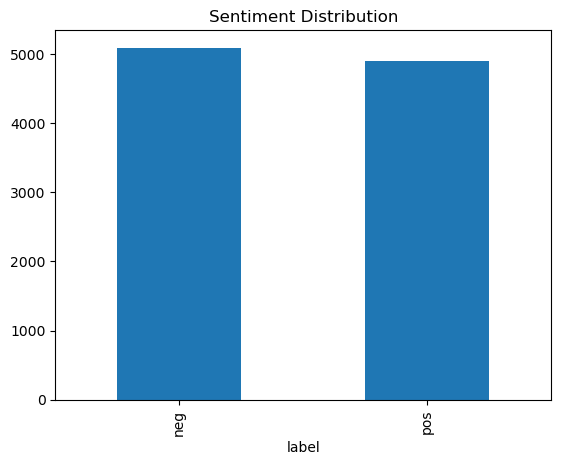

In [13]:
# Sentiment distribution
df['label'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.show()

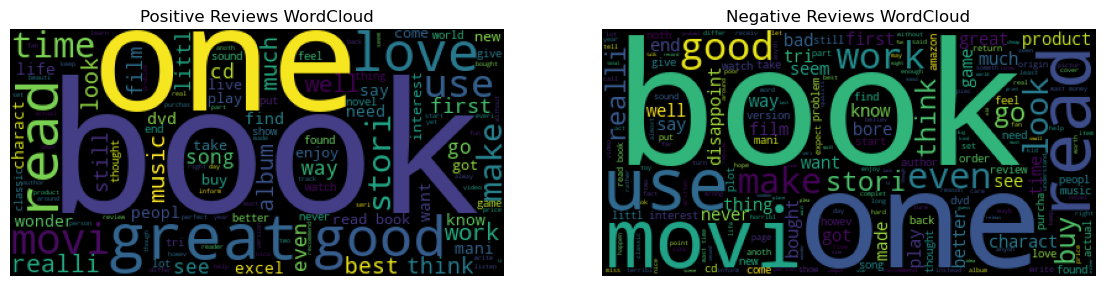

In [14]:
# WordClouds for Positive & Negative reviews
pos_text = " ".join(df[df['label']=='pos']['clean_review'])
neg_text = " ".join(df[df['label']=='neg']['clean_review'])

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.title("Positive Reviews WordCloud")
plt.imshow(WordCloud().generate(pos_text))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Negative Reviews WordCloud")
plt.imshow(WordCloud().generate(neg_text))
plt.axis("off")

plt.show()

In [15]:
# 3. Model Development

In [16]:
# Train-test split
X = df['clean_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [17]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [18]:
# Train Logistic Regression Model
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [19]:
# 4 . Evaluation

In [20]:
# Predictions
y_pred = model.predict(X_test_tfidf)

In [21]:
# Accuracy Score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.854


In [22]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         neg       0.86      0.86      0.86      1037
         pos       0.85      0.85      0.85       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



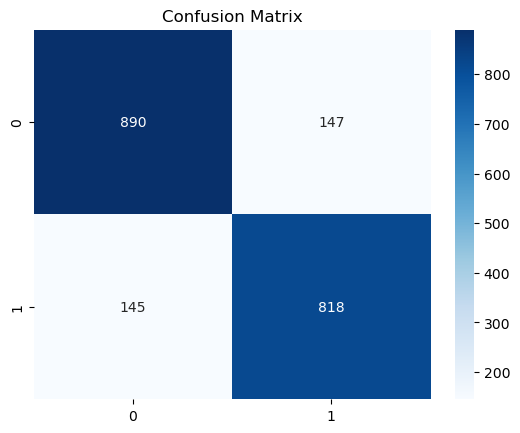

In [23]:
# Confusion Matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [24]:
# 5. Final Testing

In [25]:
# Predict your own review
review = "This product was terrible and broke immediately!"
clean = clean_text(review)
vec = tfidf.transform([clean])
print(model.predict(vec)[0])

neg
